In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pathlib import Path
import os
from embeds_utils import *

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.5, learning rate = 2e-05, regularization = 1e-06


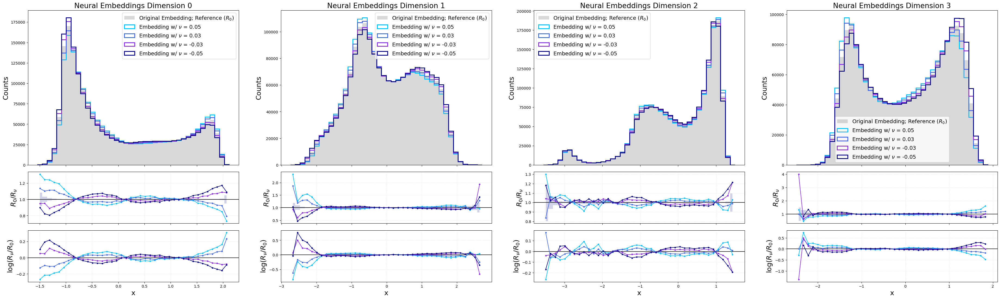

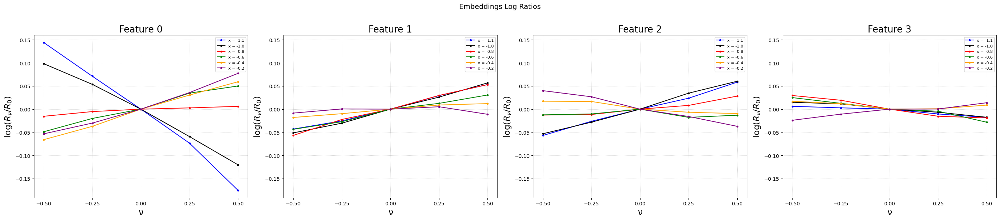

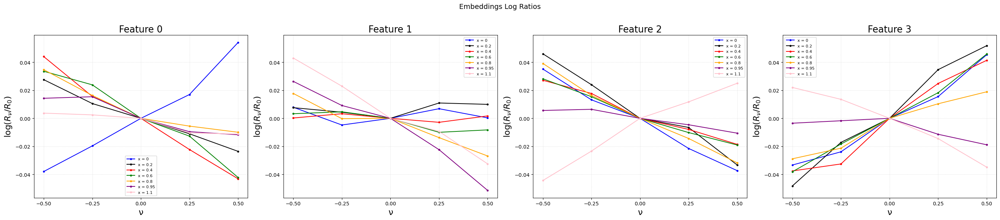

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.1, learning rate = 2e-05, regularization = 0.0001


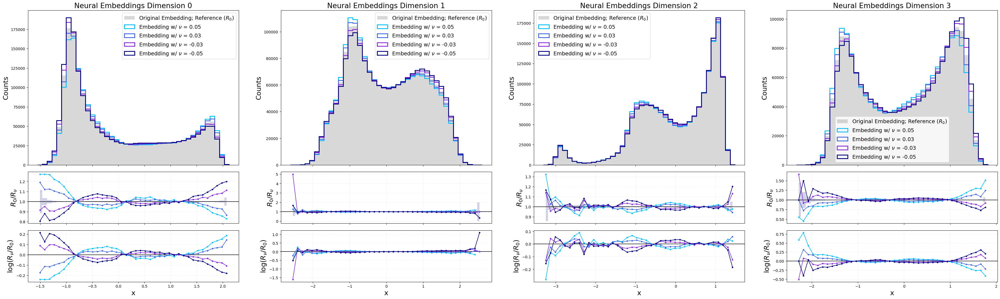

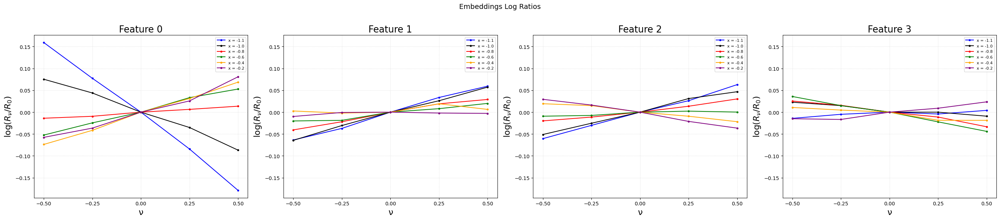

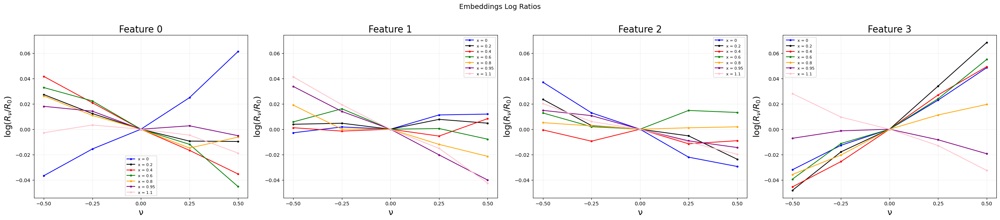

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.5, learning rate = 2e-05, regularization = 0.0001


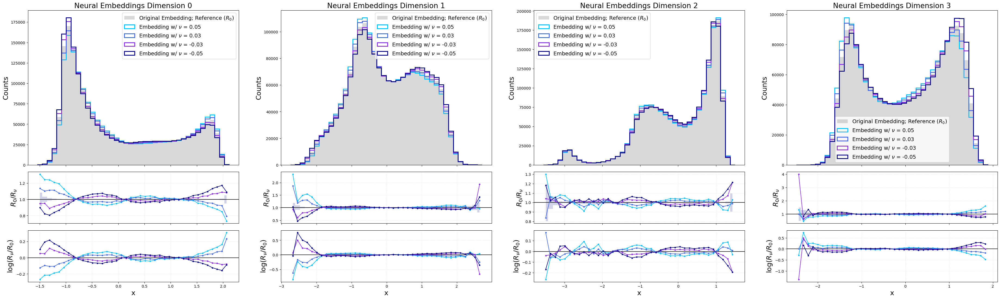

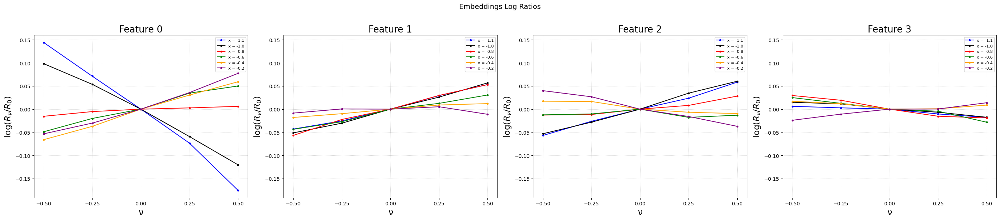

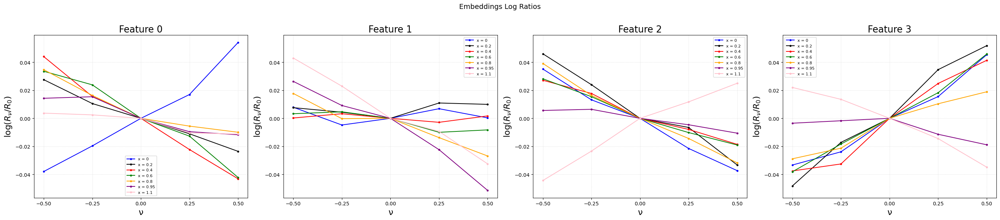

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.5, learning rate = 2e-06, regularization = 0.0001


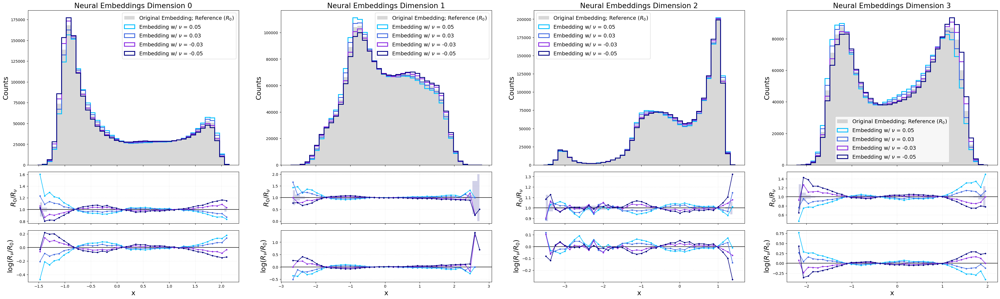

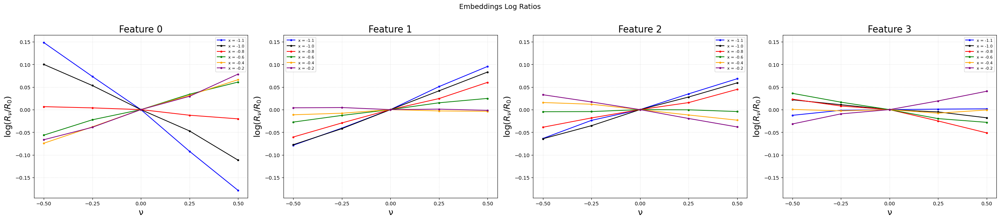

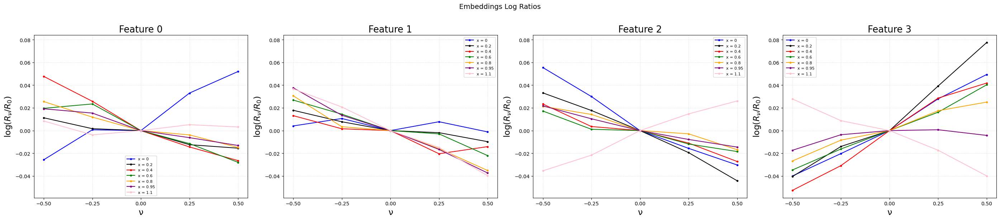

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.1, learning rate = 0.0002, regularization = 1e-06


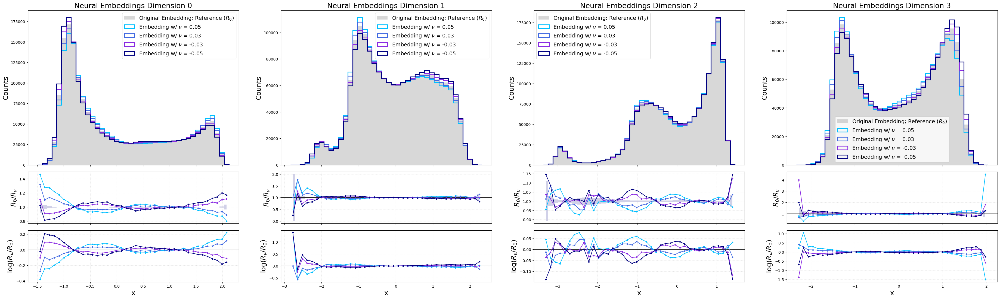

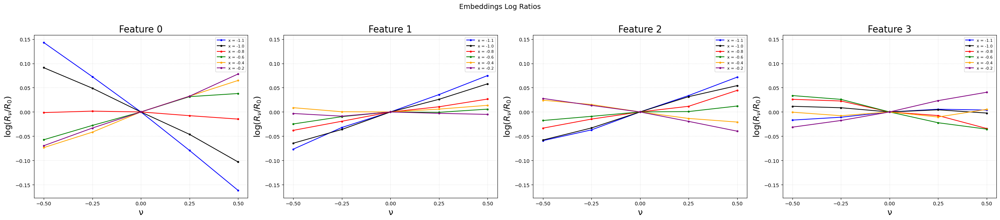

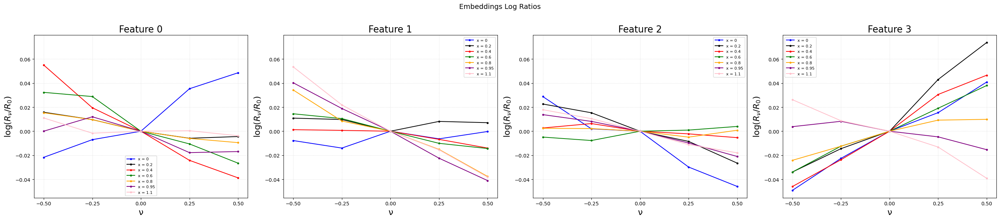

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.5, learning rate = 0.0002, regularization = 0.0001


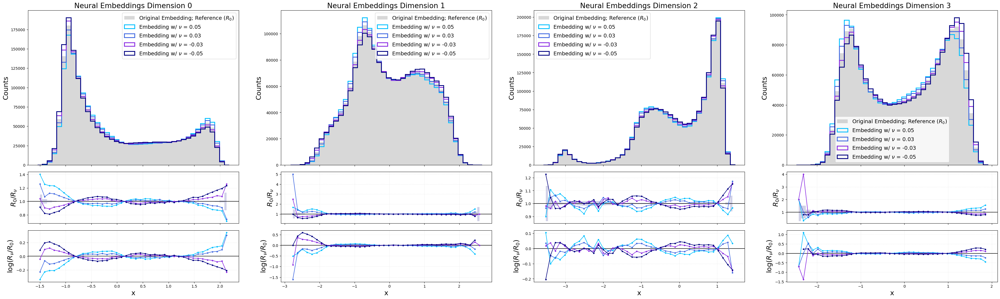

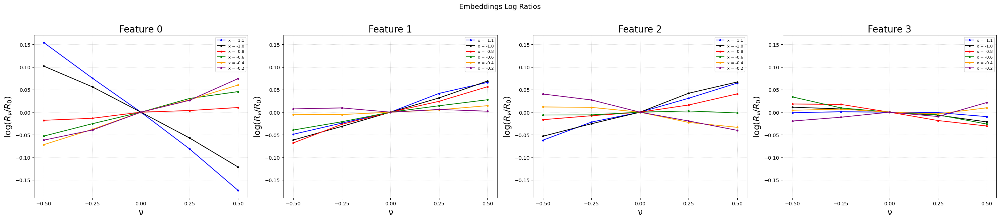

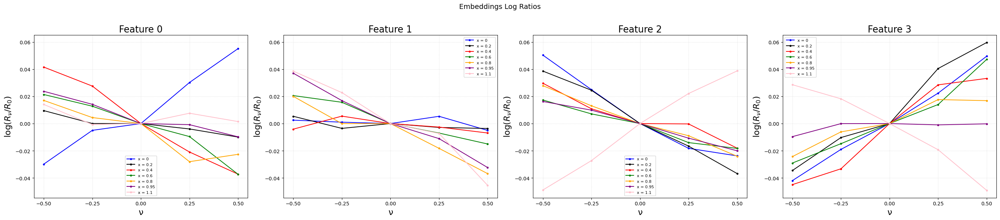

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.1, learning rate = 2e-06, regularization = 0.0001


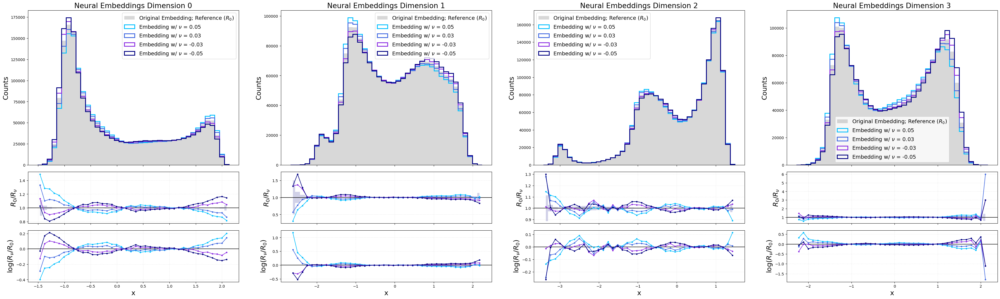

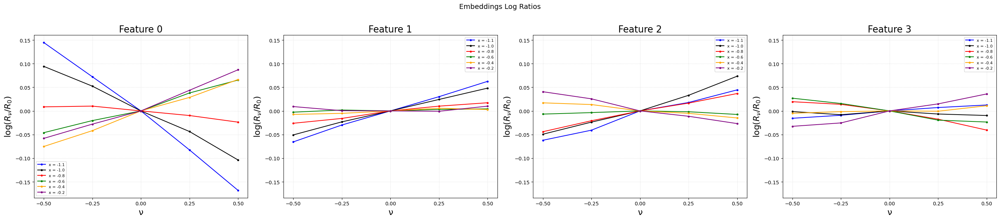

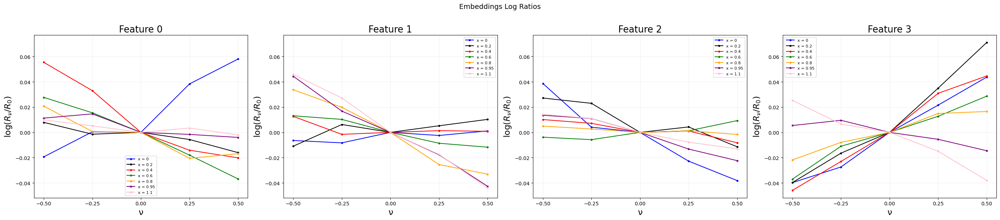

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.1, learning rate = 2e-06, regularization = 1e-06


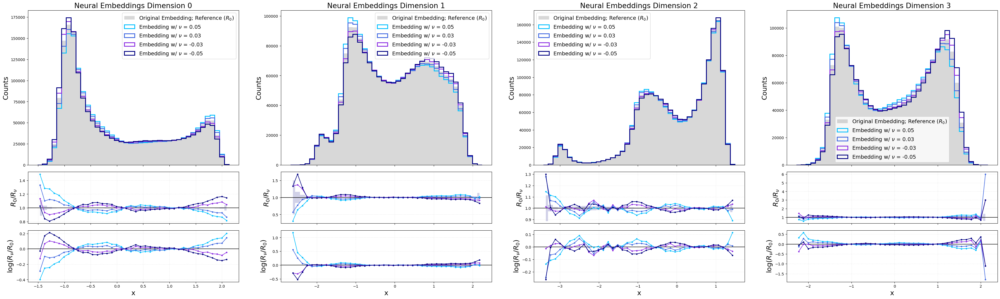

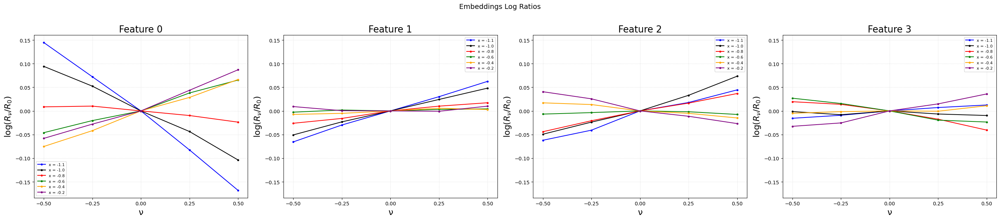

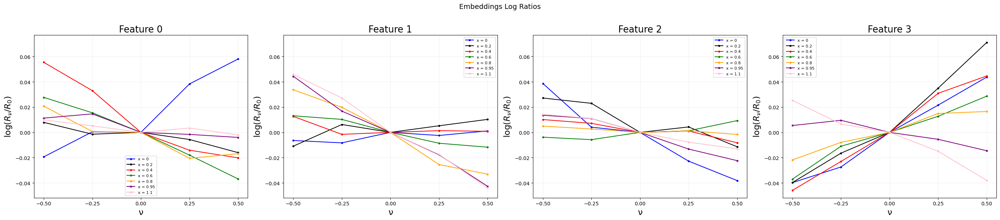

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.5, learning rate = 0.0002, regularization = 1e-06


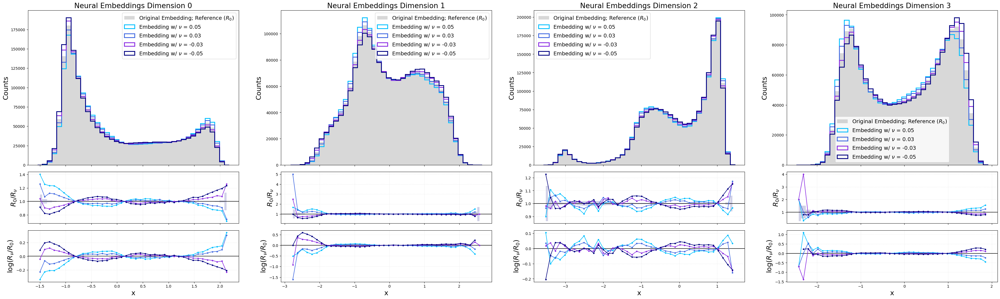

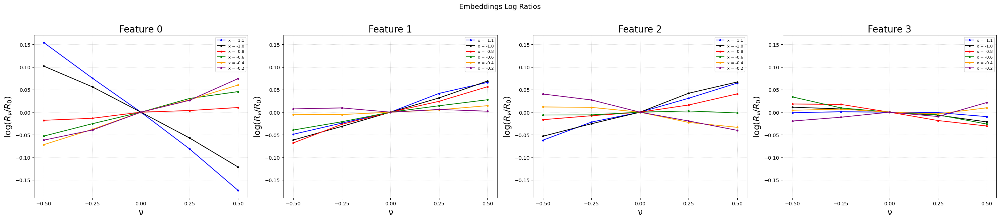

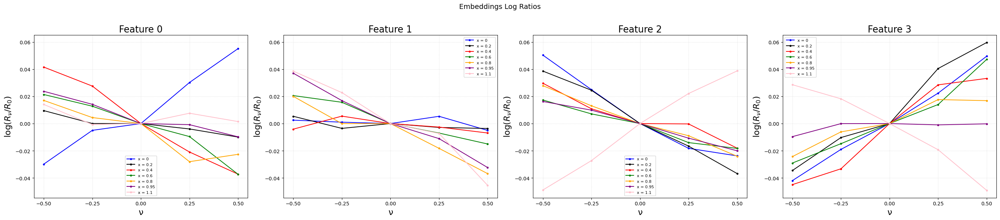

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.1, learning rate = 0.0002, regularization = 0.0001


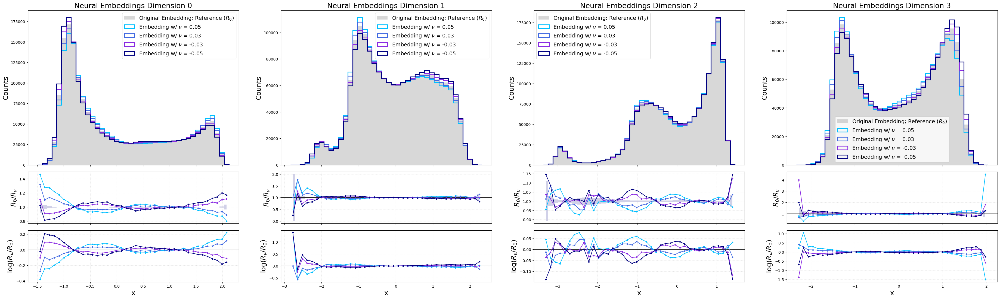

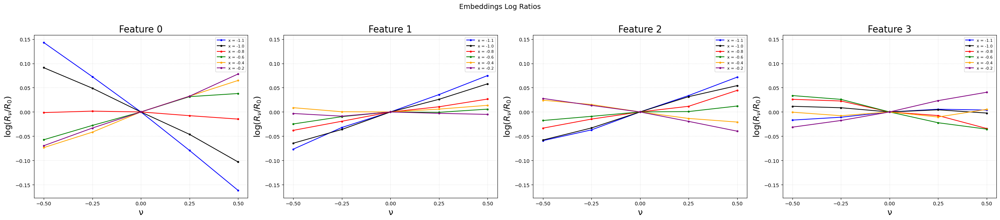

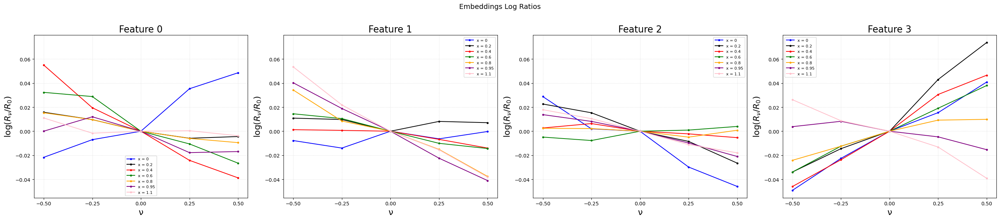

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.1, learning rate = 2e-05, regularization = 1e-06


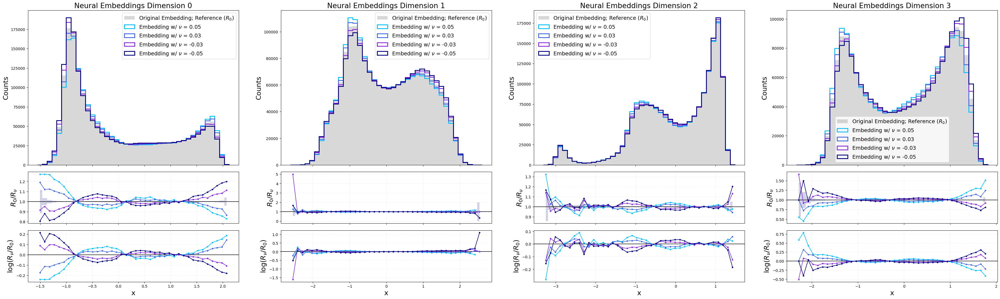

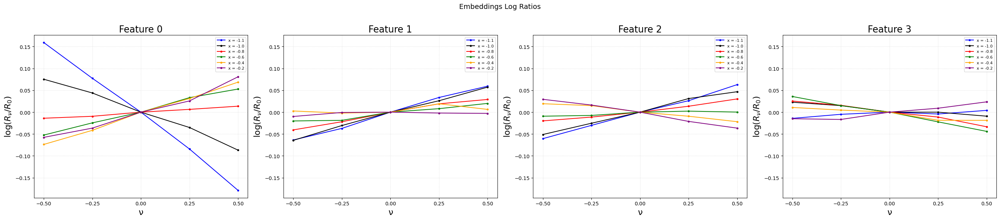

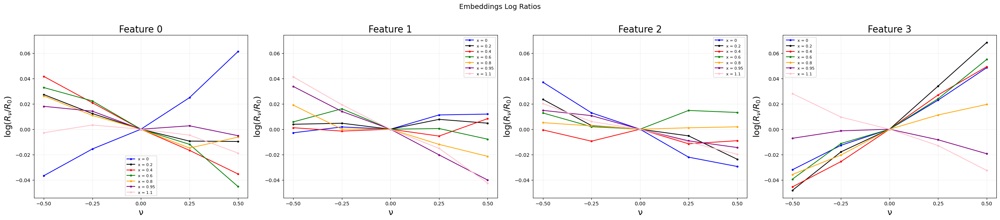

[-0.5  -0.25  0.25  0.5 ]
nv1 = 0.25, nv2 = 0.5, lambda = 0.5, learning rate = 2e-06, regularization = 1e-06


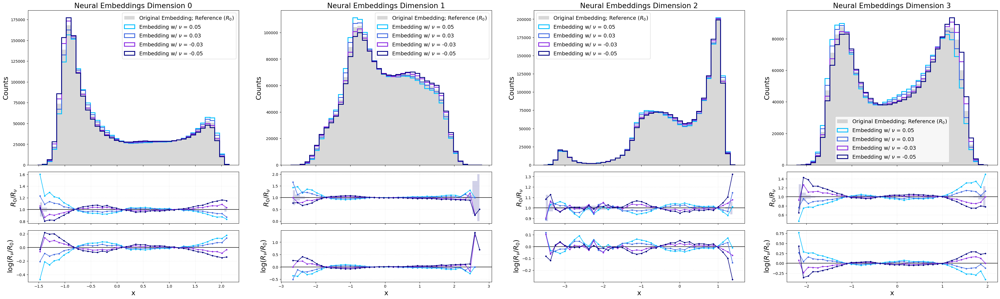

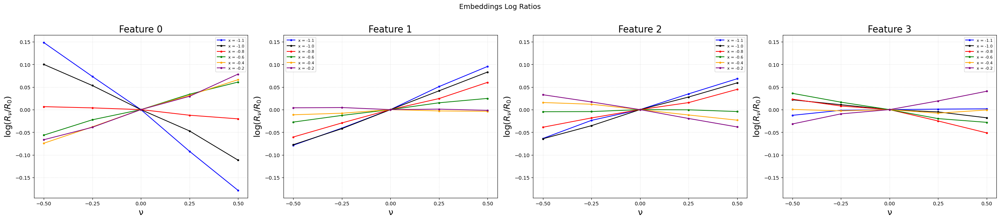

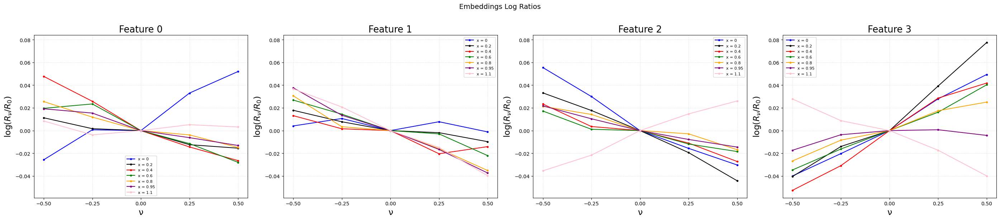

In [3]:
seed = 198439
np.random.seed(seed)
sigma_s = 0.1

N_Bkg_Pois = 1800000 #np.random.poisson(lam=200000, size=1)[0]
N_ref = 1800000
#dir_path = Path("/n/home07/tshelley2002/Uncertainty_Project/cl4ad_new/Run10/")
dir_path = Path("/n/holystore01/LABS/iaifi_lab/Users/tshelley2002/Uncertainty_Project/Run10.7/")
directory_names = [p.name for p in dir_path.iterdir()]# if (("lr3e-05" in p.name))]#and ("nv0.5_1.0" in p.name))]
#print(directory_names)

for directories in directory_names:
    
    embedding_path = os.path.join(dir_path,directories,"embedding.npz")
    
    if os.path.exists(embedding_path):
        
        parts = directories.split('_')
        nv1 = float(parts[0].replace('nv', ''))   
        nv2 = float(parts[1])                     
        lam = float(parts[2].replace('l', ''))
        lr = float(parts[3].replace('lr', ''))
        r = float(parts[4].replace('r', ''))
        nv = np.array([-nv2, -nv1, nv1, nv2])
        nv_w0 = np.array([-nv2, -nv1, 0, nv1, nv2])

        if True: #lam >= 1.5:
            print(nv)
    
            print(f"nv1 = {nv1}, nv2 = {nv2}, lambda = {lam}, learning rate = {lr}, regularization = {r}")
            
            feature_np,filename = LoadData(embedding_path,N_Bkg_Pois,N_ref,nv)
            
            plot_stephist_with_ratio_v1(feature_np, filename,N_Bkg_Pois,N_ref,nv,
                                     )
            plot_log_sbs([feature_np], [filename], N_Bkg_Pois,N_ref,nv_w0,
                        [-1.1,-1.0,-0.8,-0.6,-0.4,-0.2,])
            plot_log_sbs([feature_np], [filename], N_Bkg_Pois,N_ref,nv_w0,
                        [0,0.2,0.4,0.6,0.8,0.95,1.1,])
        
        #features_np_lst.append(feature_np)
        #filename_list.append(filename)